In [31]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph
import xarray as xr

## Rotating external field

In [32]:
ellipsoid = bl.WGS84

region = [-5,5,-5,5]

coordinates = vd.scatter_points(region=region, size=1000, extra_coords= ellipsoid.mean_radius)

dipoles = (np.array([1]), np.array([1]), np.array([ellipsoid.mean_radius - 1e5]))

magnetic_moments_observed = hm.magnetic_angles_to_vec(np.array([1e19]), np.array([45]), np.array([30]))

longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

equivalent_layer = tuple(c.ravel() for c in vd.grid_coordinates(region= region, shape= (40,40), extra_coords= ellipsoid.mean_radius - 9e4))

grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region, shape=(100,100), extra_coords=ellipsoid.mean_radius - 200))

grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

In [33]:
# damping = 1e-30

# for inc in np.linspace(0, 90, 5):
#     for dec in np.linspace(0, 90, 5):
#         b_observed = sph.forward_modeling_spherical(coordinates, dipoles, magnetic_moments_observed)
#         observed_data = hm.total_field_anomaly(b_observed, inc, dec)

#         A = sph.jacobian(coordinates, equivalent_layer, 90, 0, inc, dec)
#         coefficients = sph.calculate_coefficients(observed_data, A, damping)
#         magnetic_moment_forward = hm.magnetic_angles_to_vec(np.array([1]), np.array([90]), np.array([0]))

#         grid_data = np.zeros(len(grid_coord[0]))  


#         for j in range(m):
#             dipole_forward = (equivalent_layer[0][j], equivalent_layer[1][j], equivalent_layer[2][j])
#             b_forward = sph.forward_modeling_spherical(grid_coord, dipole_forward, magnetic_moment_forward)
#             grid_data += coefficients[j] * hm.total_field_anomaly(b_forward, inc, dec)

#         b_grid = sph.forward_modeling_spherical(grid_coord, dipoles, magnetic_moments_observed)
#         grid_observed = hm.total_field_anomaly(b_grid, inc, dec)
#         diff = grid_data - grid_observed

#         print(f'Field Inclination: {inc}, Field Declination: {dec}')

#         plt.figure(figsize=(23, 5))

#         scale = vd.maxabs(grid_observed)
#         plt.subplot(1, 3, 1)
#         plt.tripcolor(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
#         plt.colorbar(label='nT')
#         plt.title('Predicted Total Field Anomaly')
#         plt.xlabel('Longitude (°)')
#         plt.ylabel('Latitude (°)')
#         plt.axis("scaled")

#         scale2 = vd.maxabs(grid_observed)
#         plt.subplot(1, 3, 2)
#         plt.tripcolor(grid_coord[0], grid_coord[1], grid_observed, cmap="seismic", vmin=-scale2, vmax=scale2)
#         plt.colorbar(label='nT')
#         plt.title('Observed Total Field Anomaly')
#         plt.xlabel('Longitude (°)')
#         plt.ylabel('Latitude (°)')
#         plt.axis("scaled")

#         scale3 = vd.maxabs(diff)
#         plt.subplot(1, 3, 3)
#         plt.tripcolor(grid_coord[0], grid_coord[1], diff, cmap="seismic", vmin=-scale3, vmax=scale3)
#         plt.colorbar(label='nT')
#         plt.title('Residuals')
#         plt.xlabel('Longitude (°)')
#         plt.ylabel('Latitude (°)')
#         plt.axis("scaled")

#         plt.show()

## Rotating dipoles

In [34]:
ellipsoid = bl.WGS84

region = [-5,5,-5,5]

coordinates = vd.scatter_points(region=region, size=1000, extra_coords= ellipsoid.mean_radius)

dipoles = vd.scatter_points(region= (-1,1,-1,1), size=1, extra_coords= ellipsoid.mean_radius - 1e5, random_state=0)

# magnetic_moments_observed = (
#     np.full((1, 1), 0.0e9),  
#     np.full((1, 1), 0.0e9),        
#     np.full((1, 1), 1.0e9)       
# )

longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

equivalent_layer = tuple(c.ravel() for c in vd.grid_coordinates(region= region, shape= (40,40), extra_coords= ellipsoid.mean_radius - 9e4))

grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region, shape=(100,100), extra_coords=ellipsoid.mean_radius - 200))

grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

In [35]:
# damping = 1e-30

# for inc in np.linspace(0, 90, 5):
#     for dec in np.linspace(0, 90, 5):
#         magnetic_moments_observed = hm.magnetic_angles_to_vec(np.array([1.0e19]), np.array([inc]), np.array([dec]))
#         b_observed = sph.forward_modeling_spherical(coordinates, dipoles, magnetic_moments_observed)
#         observed_data = hm.total_field_anomaly(b_observed, inc, dec)

#         A = sph.jacobian(coordinates, equivalent_layer, 90, 0, inc, dec)
#         coefficients = sph.calculate_coefficients(observed_data, A, damping)
#         magnetic_moment_forward = hm.magnetic_angles_to_vec(np.array([1]), np.array([90]), np.array([0]))

#         grid_data = np.zeros(len(grid_coord[0]))  

#         for j in range(m):
#             dipole_forward = (equivalent_layer[0][j], equivalent_layer[1][j], equivalent_layer[2][j])
#             b_forward = sph.forward_modeling_spherical(grid_coord, dipole_forward, magnetic_moment_forward)
#             grid_data += coefficients[j] * hm.total_field_anomaly(b_forward, inc, dec)

#         b_grid = sph.forward_modeling_spherical(grid_coord, dipoles, magnetic_moments_observed)
#         grid_observed = hm.total_field_anomaly(b_grid, inc, dec)
#         diff = grid_data - grid_observed

#         print(f'Sources Inclination: {inc}, Sources Declination: {dec}')

#         plt.figure(figsize=(23, 5))

#         scale = vd.maxabs(grid_observed)
#         plt.subplot(1, 3, 1)
#         plt.tripcolor(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
#         plt.colorbar(label='nT')
#         plt.title('Predicted Total Field Anomaly')
#         plt.xlabel('Longitude (°)')
#         plt.ylabel('Latitude (°)')
#         plt.axis("scaled")

#         scale2 = vd.maxabs(grid_observed)
#         plt.subplot(1, 3, 2)
#         plt.tripcolor(grid_coord[0], grid_coord[1], grid_observed, cmap="seismic", vmin=-scale2, vmax=scale2)
#         plt.colorbar(label='nT')
#         plt.title('Observed Total Field Anomaly')
#         plt.xlabel('Longitude (°)')
#         plt.ylabel('Latitude (°)')
#         plt.axis("scaled")

#         scale3 = vd.maxabs(diff)
#         plt.subplot(1, 3, 3)
#         plt.tripcolor(grid_coord[0], grid_coord[1], diff, cmap="seismic", vmin=-scale3, vmax=scale3)
#         plt.colorbar(label='nT')
#         plt.title('Residuals')
#         plt.xlabel('Longitude (°)')
#         plt.ylabel('Latitude (°)')
#         plt.axis("scaled")

#         plt.show()

## Multi-dipole syntetic data

In [36]:
ellipsoid = bl.WGS84


region = [-10,10,-10,10]
height = ellipsoid.mean_radius
coordinates = tuple(c.ravel() for c in vd.scatter_points(region, size=1500,extra_coords=height))
inclination, declination = 45, 20

In [37]:
# Syntetic Dipoles
dipole_coordinates = (np.array([-6]), np.array([6]), np.array([ellipsoid.mean_radius - 5e5]))
magnetic_field = sph.forward_modeling_spherical(coordinates,
    dipoles=dipole_coordinates,
    magnetic_moments=hm.magnetic_angles_to_vec(1e12, inclination, declination)
)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

dipole2_coordinates = (np.array([0]), np.array([0]), np.array([ellipsoid.mean_radius - 5e5]))
magnetic_field = sph.forward_modeling_spherical(
    coordinates,
    dipoles=dipole2_coordinates,
    magnetic_moments=hm.magnetic_angles_to_vec(1e12, inclination, declination)
)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

dipole3_coordinates = (np.array([7]), np.array([-7]), np.array([ellipsoid.mean_radius - 1e6]))
magnetic_field = sph.forward_modeling_spherical(
    coordinates,
    dipoles=dipole3_coordinates,
    magnetic_moments=hm.magnetic_angles_to_vec(5e12, inclination, declination)
)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

(np.float64(-10.980221884911455),
 np.float64(10.997992376632407),
 np.float64(-10.997657374346852),
 np.float64(10.994129571069967))

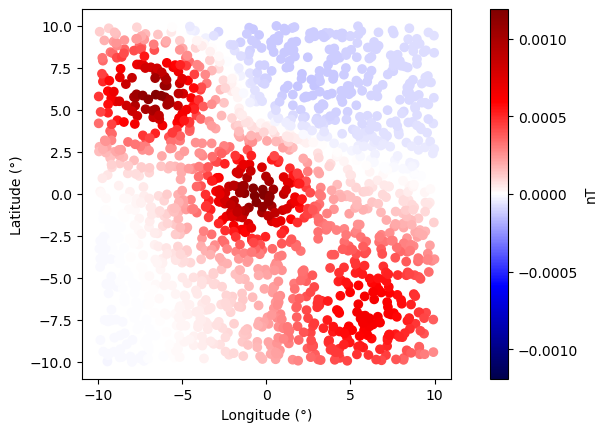

In [38]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [39]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 4.30e5

)

# equivalent_layer = tuple(c.ravel() for c in vd.grid_coordinates(region= region, shape= (40,40), extra_coords= ellipsoid.mean_radius - 9e4))

print(equivalent_layer)

equivalent_layer_inclination = 90
equivalent_layer_declination = 0 

A = sph.jacobian(coordinates, equivalent_layer, equivalent_layer_inclination, equivalent_layer_declination, inclination, declination)

(array([6.21234539, 0.25508539, 3.87088349, ..., 7.05653227, 3.142154  ,
       1.97743529]), array([ 2.0343192 , -9.04489549, -3.61958989, ...,  1.51454736,
        1.21094757,  0.60829914]), array([5941008.77141506, 5941008.77141506, 5941008.77141506, ...,
       5941008.77141506, 5941008.77141506, 5941008.77141506]))


In [40]:
damping = 1e-30
coefficients = sph.calculate_coefficients(magnetic_anomaly, A, damping)

In [41]:
# Make the coordinates of a regular grid
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region, shape=(50,50), extra_coords=ellipsoid.mean_radius + 200))

grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

magnetic_moment_foward = hm.magnetic_angles_to_vec(np.array([1]), np.array([(equivalent_layer_inclination)]), np.array([(equivalent_layer_declination)]))

for j in range(m):
    dipole_foward = (equivalent_layer[0][j],equivalent_layer[1][j],equivalent_layer[2][j])
    b_foward = sph.forward_modeling_spherical(grid_coord,dipole_foward,magnetic_moment_foward)
    grid_data += coefficients[j] * hm.total_field_anomaly(b_foward, inclination, declination)

In [42]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
  
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)

    for dipole_coordinates, moment in zip(dipole_data, moments):
        magnetic_field = sph.forward_modeling_spherical(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)
    
    return grided_magnetic_anomaly

In [43]:
dipole_data = [dipole_coordinates, dipole2_coordinates, dipole3_coordinates]

grided_magnetic_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, (1e12, 1e12, 5e12))


In [44]:
diff = grid_data - grided_magnetic_anomaly

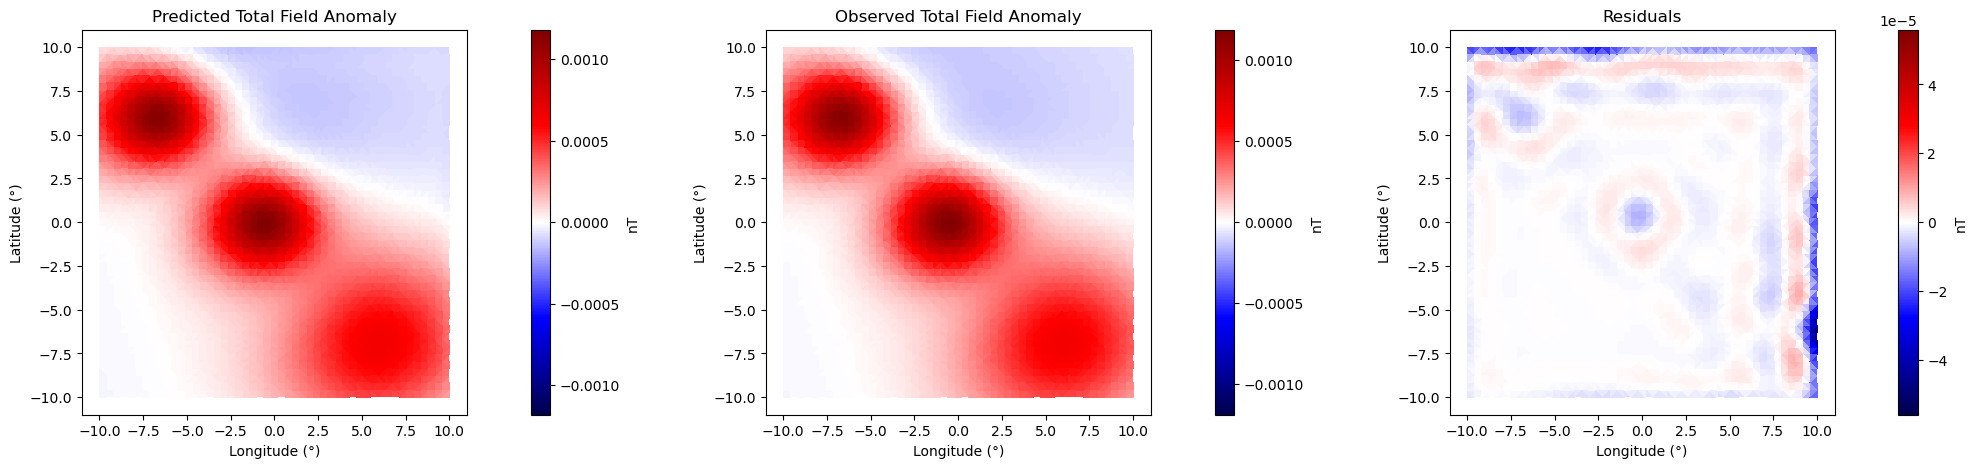

In [45]:
plt.figure(figsize=(25, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1,3,1)
plt.tripcolor(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Predicted Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale2 = vd.maxabs(magnetic_anomaly)
plt.subplot(1,3,2)
plt.tripcolor(grid_coord[0], grid_coord[1], grided_magnetic_anomaly, cmap="seismic", vmin=-scale2, vmax=scale2)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale3 = vd.maxabs(diff)
plt.subplot(1,3,3)
plt.tripcolor(grid_coord[0], grid_coord[1], diff, cmap="seismic", vmin=-scale3, vmax=scale3)
plt.colorbar(label='nT')
plt.title('Residuals')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

plt.show()

## Adding dike with profile points function

In [46]:
ellipsoid = bl.WGS84

region = [-10,10,-10,10]
height = ellipsoid.mean_radius
coordinates = tuple(c.ravel() for c in vd.scatter_points(region, size=1500 ,extra_coords=height))
inclination, declination = 90, 20

In [47]:
# Syntetic Dike
dike_size = 1000
dike_1 = sph.profile_points((10,10), (0,0), dike_size, ellipsoid.mean_radius - 4.5e4)

In [48]:
magnetic_moments_dike = hm.magnetic_angles_to_vec(
    np.full(dike_size, 1e9),  
    np.full(dike_size, inclination),  
    np.full(dike_size, declination)   
)


b_observed = sph.forward_modeling_spherical(coordinates, dike_1, magnetic_moments_dike)
dike_data = hm.total_field_anomaly(b_observed, inclination, declination)

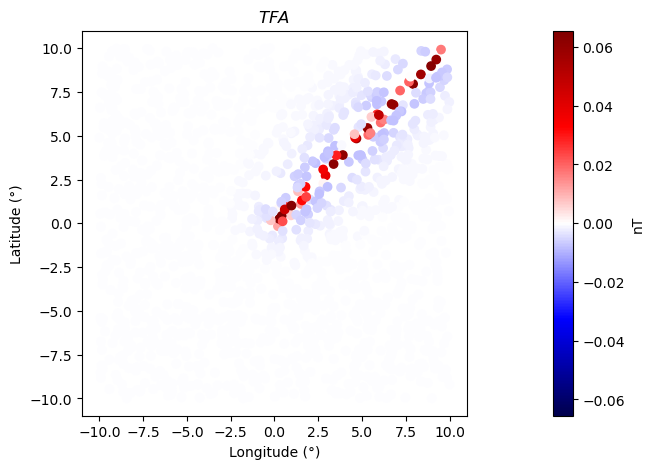

In [49]:
scale = vd.maxabs(dike_data)

plt.figure(figsize=(8, 5))
plt.scatter(coordinates[0], coordinates[1], c = dike_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('$TFA$')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")
plt.show()

In [50]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 8e4
)



A = sph.jacobian(coordinates, equivalent_layer, 90, 0, inclination, declination)

damping = 1e-30

coefficients = sph.calculate_coefficients(dike_data, A, damping)

In [51]:
# Make the coordinates of a regular grid
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region, shape=(100,100), extra_coords=ellipsoid.mean_radius - 200))

grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

magnetic_moment_foward = hm.magnetic_angles_to_vec(np.array([1]), np.array([(90)]), np.array([(0)]))

for j in range(m):
    dipole_foward = (equivalent_layer[0][j],equivalent_layer[1][j],equivalent_layer[2][j])
    b_foward = sph.forward_modeling_spherical(grid_coord,dipole_foward,magnetic_moment_foward)
    grid_data += coefficients[j] * hm.total_field_anomaly(b_foward, inclination, declination)

In [52]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
    
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)


    dipole_latitudes, dipole_longitudes, dipole_radii = dipole_data

    for lat, lon, r, moment in zip(dipole_latitudes.flatten(), dipole_longitudes.flatten(), dipole_radii.flatten(), moments):
        dipole_coordinates = np.array([lat, lon, r])
        
        magnetic_field = sph.forward_modeling_spherical(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

    return grided_magnetic_anomaly

In [53]:
grided_dike_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dike_1, np.full(dike_size, 1e9))
diff = grid_data - grided_dike_anomaly

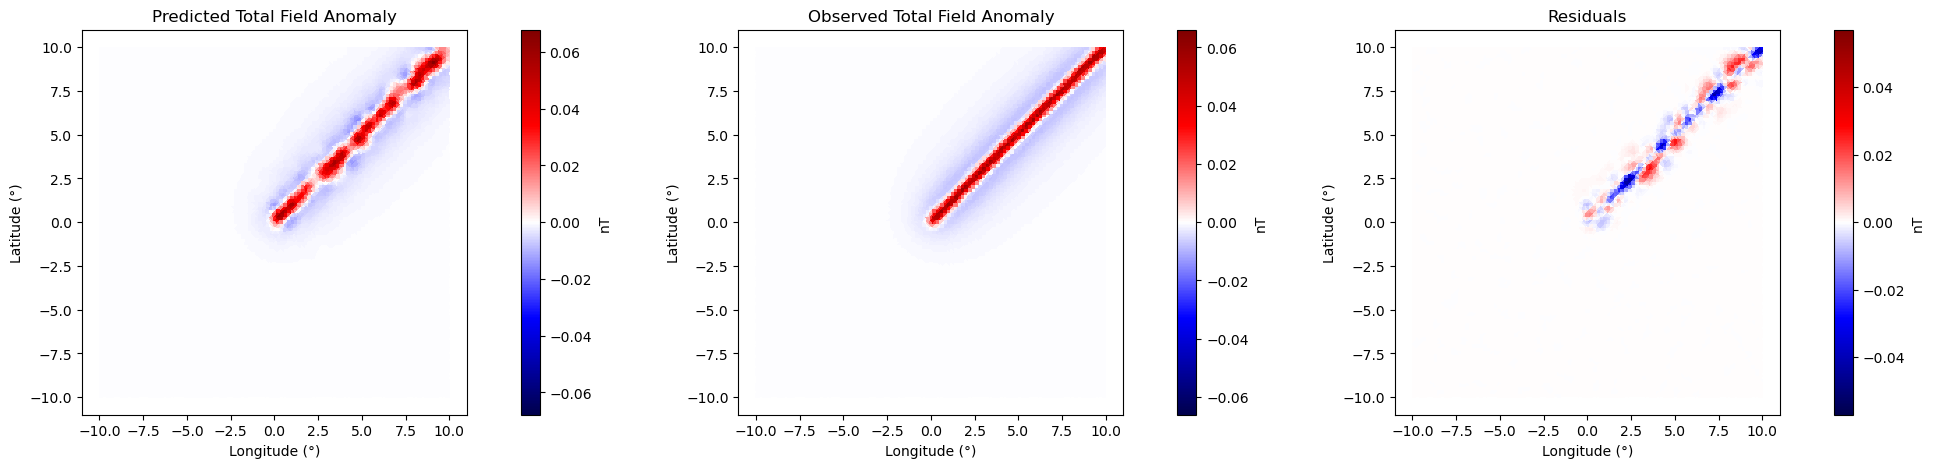

In [54]:
plt.figure(figsize=(24, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1,3,1)
plt.tripcolor(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Predicted Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale2 = vd.maxabs(grided_dike_anomaly)
plt.subplot(1,3,2)
plt.tripcolor(grid_coord[0], grid_coord[1], grided_dike_anomaly, cmap="seismic", vmin=-scale2, vmax=scale2)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale3 = vd.maxabs(diff)
plt.subplot(1,3,3)
plt.tripcolor(grid_coord[0], grid_coord[1], diff, cmap="seismic", vmin=-scale3, vmax=scale3)
plt.colorbar(label='nT')
plt.title('Residuals')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

plt.show()

### Using dikes and dipoles

In [55]:
ellipsoid = bl.WGS84

region = [-10,10,-10,10]
height = ellipsoid.mean_radius
coordinates = tuple(c.ravel() for c in vd.scatter_points(region, size=1000,extra_coords=height))
inclination, declination = 30, 20

In [56]:
# Syntetic dike

dike_size = 100
dike = sph.profile_points((10,-5), (-10,-7.5), dike_size, ellipsoid.mean_radius - 8.0e4)

# Syntetic dipoles
n_dipoles = 3
dipoles = tuple(c.ravel() for c in vd.scatter_points(region= (-10,0,-10,10), size= n_dipoles, extra_coords= ellipsoid.mean_radius - 4e5, random_state=5))

#Data

magnetic_field = sph.forward_modeling_spherical(coordinates,
    dipoles,
magnetic_moments = hm.magnetic_angles_to_vec(
    np.full(n_dipoles, 1e12),  
    np.full(n_dipoles, inclination),  
    np.full(n_dipoles, declination)   
)
)
dike_and_dipoles = hm.total_field_anomaly(magnetic_field, inclination, declination)

magnetic_moments_dike = hm.magnetic_angles_to_vec(
    np.full(dike_size, 1e9),  
    np.full(dike_size, inclination),  
    np.full(dike_size, declination)   
)


magnetic_field = sph.forward_modeling_spherical(coordinates, dike, magnetic_moments_dike)

dike_and_dipoles += hm.total_field_anomaly(magnetic_field, inclination, declination)

(np.float64(-10.996790157247304),
 np.float64(10.987079212184256),
 np.float64(-10.996388378863344),
 np.float64(10.9963849982421))

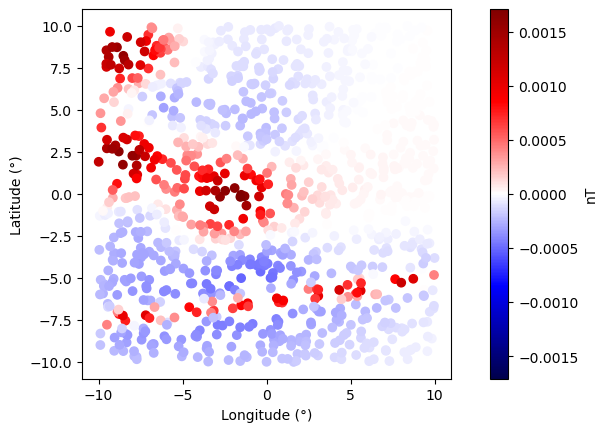

In [62]:
scale = vd.maxabs(dike_and_dipoles)
plt.scatter(coordinates[0], coordinates[1],  c = dike_and_dipoles, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [58]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 1.9e5
)


eql_inc = 90
eql_dec = 0
A = sph.jacobian(coordinates, equivalent_layer, eql_inc, eql_dec, inclination, declination)

damping = 1e-30

coefficients = sph.calculate_coefficients(dike_and_dipoles, A, damping)

In [59]:
# Make the coordinates of a regular grid
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region, spacing=0.09, extra_coords=ellipsoid.mean_radius - 200))

grid_data = np.zeros(np.shape(grid_coord[0]))

m = equivalent_layer[0].size

magnetic_moment_foward = hm.magnetic_angles_to_vec(np.array([1]), np.array([(eql_inc)]), np.array([(eql_dec)]))

for j in range(m):
    dipole_foward = (equivalent_layer[0][j],equivalent_layer[1][j],equivalent_layer[2][j])
    b_foward = sph.forward_modeling_spherical(grid_coord,dipole_foward,magnetic_moment_foward)
    grid_data += coefficients[j] * hm.total_field_anomaly(b_foward, inclination, declination)

In [60]:
grided_dd_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dike, np.full(dike_size, 1e9))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, dipoles, np.full(n_dipoles ,1e12))
diff = grid_data - grided_dd_anomaly

(np.float64(-11.0), np.float64(11.0), np.float64(-11.0), np.float64(11.0))

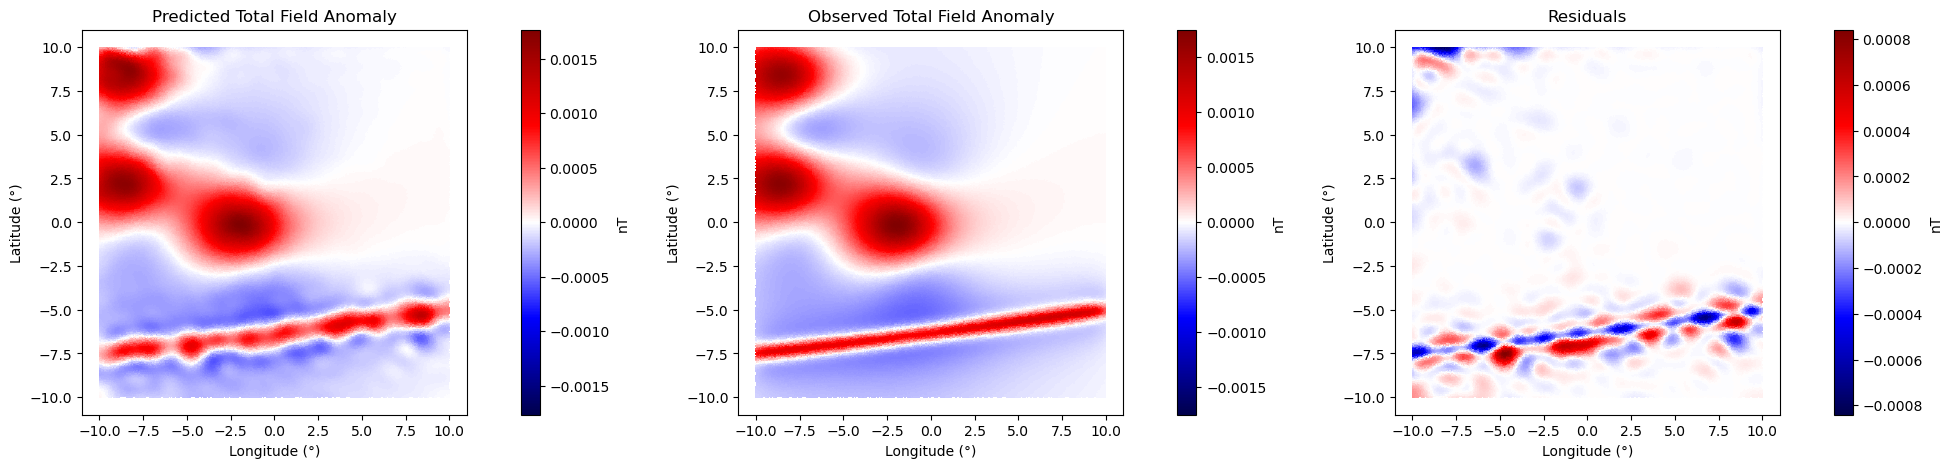

In [61]:
plt.figure(figsize=(24, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1,3,1)
plt.tripcolor(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Predicted Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale2 = vd.maxabs(grided_dd_anomaly)
plt.subplot(1,3,2)
plt.tripcolor(grid_coord[0], grid_coord[1], grided_dd_anomaly, cmap="seismic", vmin=-scale2, vmax=scale2)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

scale3 = vd.maxabs(diff)
plt.subplot(1,3,3)
plt.tripcolor(grid_coord[0], grid_coord[1], diff, cmap="seismic", vmin=-scale3, vmax=scale3)
plt.colorbar(label='nT')
plt.title('Residuals')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")
